# To check RF position to QDSPY coordinate transrom

### imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import hydra
from hydra.utils import get_original_cwd
import os
from omegaconf import DictConfig, OmegaConf
from dataclasses import dataclass
from typing import List, Dict, Any

from IPython.display import display



In [3]:
# Load config
import sys
import os
from pathlib import Path


# Add the parent directory to the path so we can import modules properly
cwd = Path.cwd()
print(f"home directory: {cwd}")
relative_repo_path = "GitRepos/simulation_closed_loop"

# append repo path 
sys.path.append(str(cwd / relative_repo_path))

# Import Hydra config utilities
from omegaconf import DictConfig, OmegaConf
import hydra
from hydra.utils import instantiate
from hydra.core.config_store import ConfigStore
from hydra import compose, initialize

# Initialize Hydra with the relative path to the config directory
config_path = os.path.join(relative_repo_path,"config")
print(f"Config path: {config_path}")

# Initialize Hydra
with initialize(version_base="1.3", config_path=config_path):
    # Compose the configuration
    cfg = compose(config_name="config")

# Print the config to verify it loaded correctly
print("Configuration loaded successfully:")
print(OmegaConf.to_yaml(cfg))



home directory: /gpfs01/euler/User/ssuhai
Config path: GitRepos/simulation_closed_loop/config
Configuration loaded successfully:
data_subfolders:
  day: 20250717
  experiment: 1
DJ:
  username: ssuhai
  userinfo:
    experimenter: closedlooptest
    animal_loc: 1
    region_loc: 2
    field_loc: 3
    stimulus_loc: 4
    cond1_loc: 5
    data_dir: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_rfs
  table_parameters:
    PreprocessParams:
      fs_resample: 60
    Stimulus:
      noise:
        stim_name: densenoise
        stim_family: noise
        pix_n_x: 20
        pix_n_y: 15
        skip_duplicates: true
        pix_scale_x_um: 40
        pix_scale_y_um: 40
        framerate: 5
    DNoiseTraceParams:
      dnoise_params_id: 1
      fupsample_trace: 20
      fupsample_stim: 4
      ref_time: stim
      fit_kind: gradient
      skip_duplicates: true
      pre_blur_sigma_s: 0.0
      post_blur_sigma_s: 0.0
paths:
  repo_directory: /gpfs01/euler/User/

In [4]:
from simulations.loop_components.dj_wrappers import DJTableHolder,Preprocessor,QualityAndTypeWrapper,STAWrapper,RandomSeedMEIWrapper
from simulations.loop_components.recording_file_copier import copy_rec_files,create_directory_structure
#from simulations.loop_components.stimulus import create_rf_avi_from_roi_ids


### Create processing components (connect them to DB)

In [5]:
# create preprocessor
os.environ["DJ_SUPPORT_FILEPATH_MANAGEMENT"] = "TRUE"

dj_table_holder = DJTableHolder(
                username=cfg.DJ.username, # type: ignore
                
                #paths
                home_directory=cfg.paths.home_directory, # type: ignore
                repo_directory=cfg.paths.repo_directory, # type: ignore
                dj_config_directory= cfg.paths.dj_config_directory, # type: ignore
                rgc_output_directory= cfg.paths.rgc_output_directory, # type: ignore
                data_subfolders=cfg.data_subfolders, # type: ignore


                userinfo= cfg.DJ.userinfo, # type: ignore

                table_parameters=cfg.DJ.table_parameters, # type: ignore

                # from overall configs
                debug=cfg.debug, # type: ignore
                plot_results=cfg.plot_results, # type: ignore

                    )



In [82]:

# Load config and tables
dj_table_holder.load_config()
dj_table_holder.load_tables()
print(" loaded and configured successfully")
# dj_table_holder.clear_tables("experiment")

# dj_table_holder.setup()




schema_name: ageuler_ssuhai_closed_loop
 loaded and configured successfully


In [7]:
preprocessor = Preprocessor(dj_table_holder=dj_table_holder)


quality_type_analysis_wrapper = QualityAndTypeWrapper(
    dj_table_holder=dj_table_holder,)

sta_wrapper = STAWrapper(
    dj_table_holder=dj_table_holder,)


random_seed_mei_wrapper = RandomSeedMEIWrapper(
    dj_table_holder=dj_table_holder,
    model_configs=cfg.model_configs, 
    seeds= [123,456,789])

## During the experimet

### Move files from server to the repo 

In [8]:
create_directory_structure(base_directory= cfg.DJ.userinfo.data_dir,
                           date=  cfg.data_subfolders.day, 
                           experiment = cfg.data_subfolders.experiment)

copy_rec_files(
    recording_files_dir=cfg.paths.recording_files_dir,  # type: ignore
    destination_base=cfg.DJ.userinfo.data_dir,  # type: ignore
    date=cfg.data_subfolders.day,  # type: ignore
    experiment=cfg.data_subfolders.experiment,  # type: ignore
    full_dummy_ini_dir= os.path.join(cfg.paths.repo_directory, cfg.paths.dummy_ini_dir),  # type: ignore
)

SKIPPING File M1_RR_od.smh: does not match any permissible stimulus type.
SKIPPING File M1_RR_od.smp: does not match any permissible stimulus type.
COPIED file from /gpfs01/euler/data/Data/Suhai/move_closed_loop_data_here/M1_RR_GCL1_chirp_1.smp to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_rfs/20250717/1/Raw/M1_RR_GCL1_chirp_1_iter0.smp
COPIED file from /gpfs01/euler/data/Data/Suhai/move_closed_loop_data_here/M1_RR_GCL1_MB_1.smh to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_rfs/20250717/1/Raw/M1_RR_GCL1_MB_1_iter0.smh
COPIED file from /gpfs01/euler/data/Data/Suhai/move_closed_loop_data_here/M1_RR_GCL1_chirp_1.smh to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_rfs/20250717/1/Raw/M1_RR_GCL1_chirp_1_iter0.smh
COPIED file from /gpfs01/euler/data/Data/Suhai/move_closed_loop_data_here/M1_RR_GCL1_DN_1.smh to /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_r

In [11]:
preprocessor.upload_iteration_metadata()

Scanning for experimenter: closedlooptest
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/test_rfs/20250717/1
		header_name: 20250717_left.ini
		Adding: {'experimenter': 'closedlooptest', 'date': datetime.datetime(2025, 7, 17, 0, 0), 'exp_num': 1}


OpticDisk: 100%|██████████| 1/1 [00:00<00:00, 40.41it/s]


Found 3 files in 1 fields for key={'experimenter': 'closedlooptest', 'date': datetime.date(2025, 7, 17), 'exp_num': 1, 'raw_id': 1}
	Adding field: `{'field': 'GCL1', 'region': 'RR', 'cond1': '1', 'experimenter': 'closedlooptest', 'date': datetime.date(2025, 7, 17), 'exp_num': 1, 'raw_id': 1}`


Processes: 100%|██████████| 6/6 [00:03<00:00,  1.56it/s]


### Analysis and Visualization

In [12]:
missing_keys = dj_table_holder("RoiMask")().list_missing_field()
field_key = missing_keys[0]
missing_keys
# import datetime
# test_key = {'experimenter': 'closedlooptest',
#   'date': datetime.date(2025, 7, 17),
#   'exp_num': 1,
#   'raw_id': 1,
#   'field': 'GCL1',
#   'region': 'RR',
#   'cond1': 'iter0'}
# missing_keys = [test_key]

[{'experimenter': 'closedlooptest',
  'date': datetime.date(2025, 7, 17),
  'exp_num': 1,
  'raw_id': 1,
  'field': 'GCL1',
  'region': 'RR',
  'cond1': '1'}]

In [13]:
# somehow I get a circular import error if I import this at the top
from simulations.gui.integrated_autorois import InteractiveRoiCanvas

In [ ]:
online_analysis_gui = InteractiveRoiCanvas(
    dj_table_holder=dj_table_holder,
    dj_preprocessor=preprocessor,
    all_dj_wrappers=[quality_type_analysis_wrapper,sta_wrapper,random_seed_mei_wrapper],
    field_key=field_key,
    canvas_width=30,
    )

Load model weights for cpu from checkpoint /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/dropout_and_aug_regul.ckpt using config /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/sd_images.yaml


In [15]:
display(online_analysis_gui.start_gui()) 

# Look at sRF peak and postition 

In [85]:
dj_table_holder('PeakSTAPosition')().populate()

{'success_count': 97, 'error_list': []}

In [ ]:
# show the first frame of Dnoise
import h5py
import matplotlib.pyplot as plt 
with h5py.File("/gpfs01/euler/data/Resources/Stimulus/noise.h5", "r") as f:
    noise_stimulus = f['stimulusarray'][:].T.astype(int)

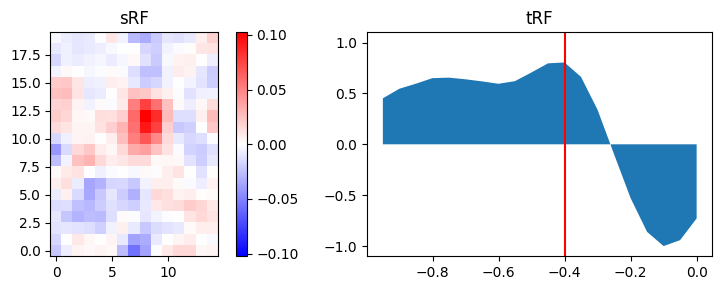

peakx 100.0 
peaky 40.0
Peak idx axis 0: 12 xis 1: 8


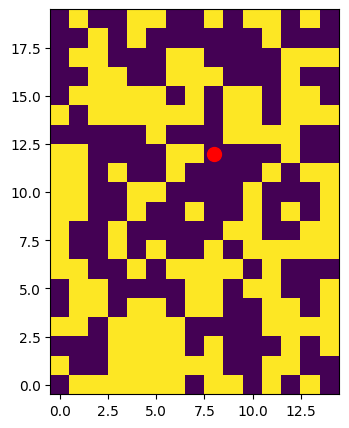

In [86]:

# roi 27 has nice RF look at peak position
def plot_srf_pos(roi_id = 27):
    pos = (dj_table_holder('PeakSTAPosition')() & {'roi_id': roi_id}).fetch(as_dict = True) # this is the roi id for the peak position
    assert len(pos) == 1, "There should be exactly one position for the given roi_id"
    pos = pos[0]

    (dj_table_holder('SplitRF')() & {'roi_id': roi_id}).plot1()
    sRF = (dj_table_holder('SplitRF')() & {'roi_id': roi_id}).fetch1('srf')

    print("peakx", pos["rf_peak_x_um"],"\npeaky", pos["rf_peak_y_um"])

    peak_idx = dj_table_holder("PeakSTAPosition").get_rf_spatial_max_indices(sRF)
    print("Peak idx axis 0:",peak_idx[0], "\axis 1:", peak_idx[1])

    fig,ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(noise_stimulus [0],origin='lower')
    ax.scatter( peak_idx[1],peak_idx[0], color='red', s=100, label='Peak Position')
plot_srf_pos(27)

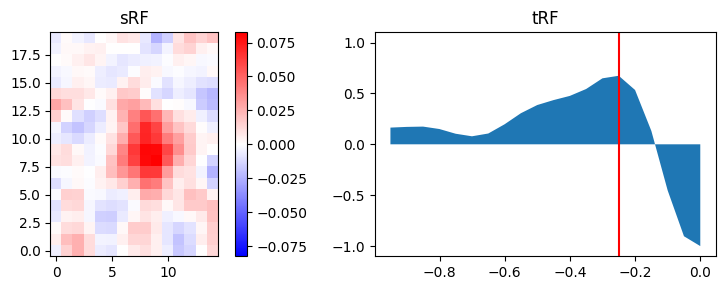

peakx -60.0 
peaky 80.0
Peak idx axis 0: 8 xis 1: 9


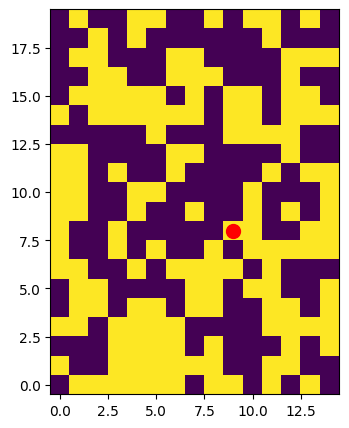

In [116]:
plot_srf_pos(44)

# In QDSpy the point appears also on the same part of the pattern so the conversion of coordinates is correct